Load the `ISLR2` and `tidyverse` packages.

In [15]:
library('ISLR2')
library('tidyverse')
library('tidymodels')

`glimpse` the `Auto` dataset (this comes from the `ISLR2` package).

In [4]:
glimpse(Auto)

Rows: 392
Columns: 9
$ mpg          <dbl> 18, 15, 18, 16, 17, 15, 14, 14, 14, 15, 15, 14, 15, 14, 2…
$ cylinders    <int> 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 4, 6, 6, 6, 4, …
$ displacement <dbl> 307, 350, 318, 304, 302, 429, 454, 440, 455, 390, 383, 34…
$ horsepower   <int> 130, 165, 150, 150, 140, 198, 220, 215, 225, 190, 170, 16…
$ weight       <int> 3504, 3693, 3436, 3433, 3449, 4341, 4354, 4312, 4425, 385…
$ acceleration <dbl> 12.0, 11.5, 11.0, 12.0, 10.5, 10.0, 9.0, 8.5, 10.0, 8.5, …
$ year         <int> 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 70, 7…
$ origin       <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 3, 1, 1, 1, 3, …
$ name         <fct> chevrolet chevelle malibu, buick skylark 320, plymouth sa…


Plot `mpg`  as a function of `displacement`.

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


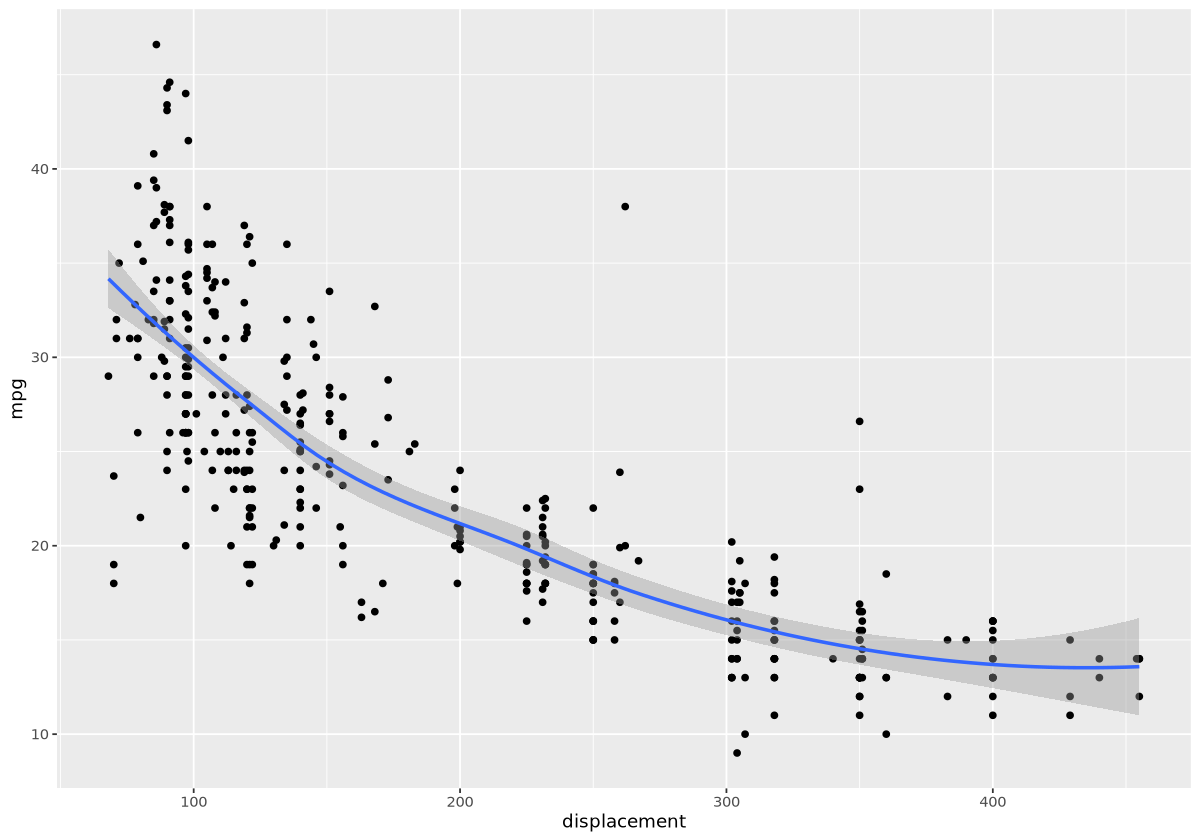

In [8]:
options(repr.plot.width = 10)
ggplot(Auto, aes(y = mpg, x = displacement)) +
    geom_point() + stat_smooth()

In [9]:
mpg_mean = Auto |> 
    group_by(displacement) |> 
    summarize(mpg = mean(mpg))

`geom_smooth()` using method = 'loess' and formula = 'y ~ x'


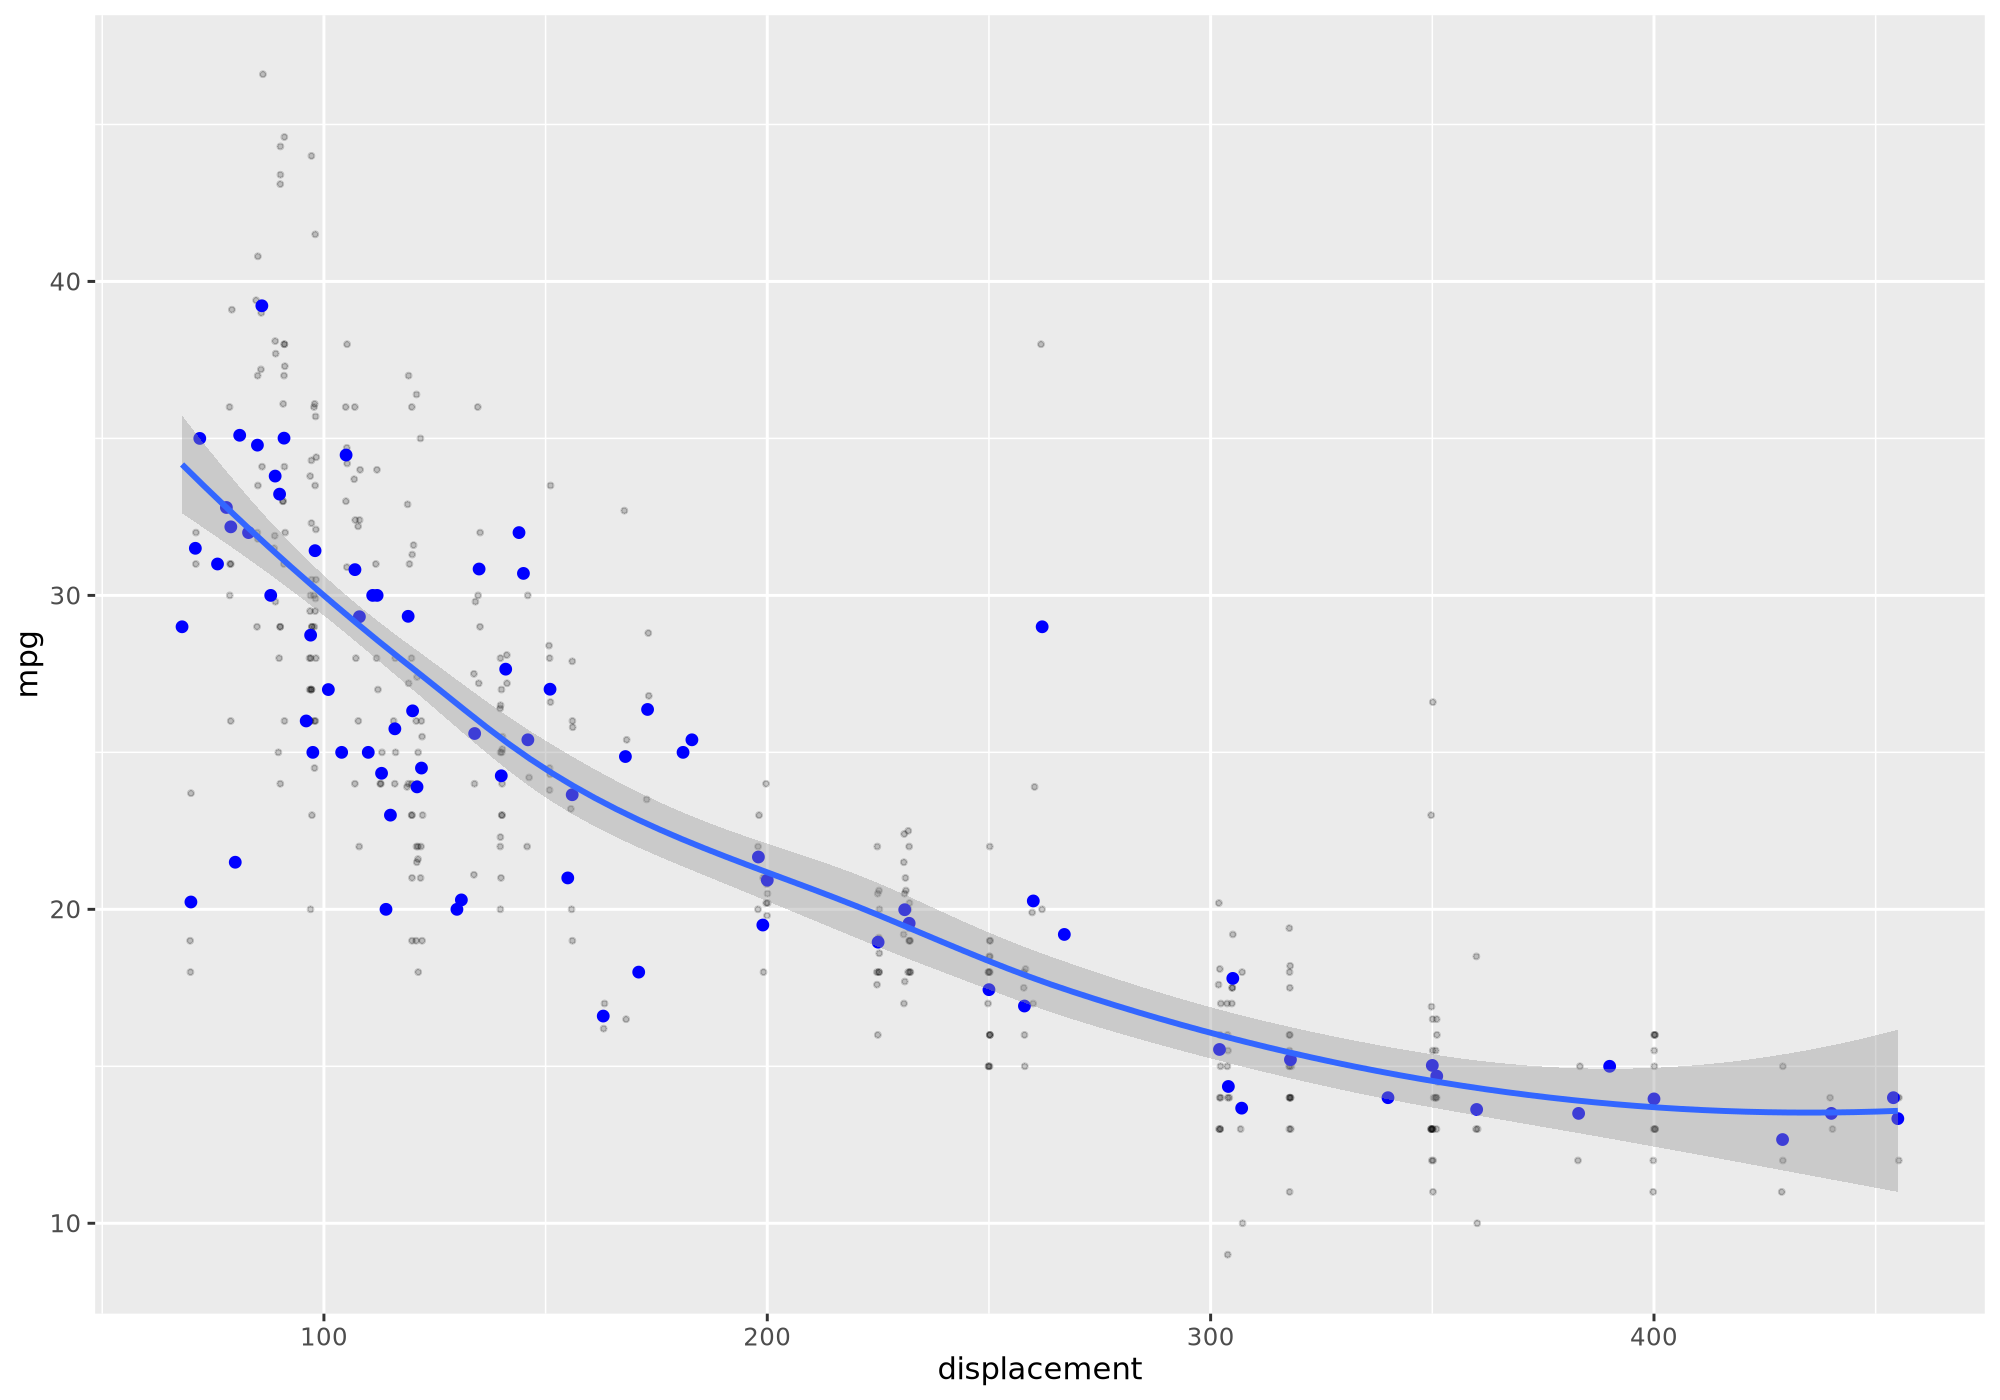

In [11]:
options(repr.plot.res = 200)

ggplot(aes(x = displacement, y = mpg), data = Auto) + 
    geom_point(alpha = 0.2, size = 0.65, position = position_jitter(width = 0.3, height = 0)) +
    geom_point(data = mpg_mean, color = 'blue') + stat_smooth()

❓Does the relationship of `mpg` to `displacement` look linear?
## The relationship of mpg to displacement does not look entirely linear. I believe that the curve in the plot indicates that the parameters affecting mpg are non-linear. 

Model `mpg` as a function of `displacement` and `cylinders`. 

- Transform the `displacement` variable using a `spline` or `polynomial` transform. (Hint: use `step_ns` or `step_poly`).
- Combine `step_mutate(cyl_cat = factor(cylinders))` followed by `step_dummy(cyl_cat)` and `step_rm(cylinders)` to convert `cylinders` to categorical data for the model.

Assuming you name your fitted model `mod_fit` the code below can be used to visualize your model:

```r
predict(mod_fit, rec |> juice()) |>
    bind_cols(Auto) |>
ggplot(aes(x = displacement, y = mpg)) +
    geom_point(size = 1, alpha = 0.35) +
    geom_line(aes(y = .pred, color = factor(cylinders)), linewidth = 1)
```

**Create and visualize your model below...**

In [23]:
rec = recipe(mpg ~ displacement + cylinders, data = Auto) |>
    step_poly(displacement, degree = 3) |>
    step_mutate(cyl_cat = factor(cylinders)) |>
    step_dummy(cyl_cat) |>
    step_rm(cylinders) |>
    prep()

juice(rec) |> head()

mpg,displacement_poly_1,displacement_poly_2,displacement_poly_3,cyl_cat_X4,cyl_cat_X5,cyl_cat_X6,cyl_cat_X8
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
18,0.05441134,-0.03507716,-0.05454942,0,0,0,1
15,0.07519231,0.01040418,-0.05893726,0,0,0,1
18,0.05972740,-0.02535046,-0.05990253,0,0,0,1
16,0.05296150,-0.03750222,-0.05268692,0,0,0,1
17,0.05199495,-0.03906473,-0.05135787,0,0,0,1
15,0.11337129,0.14620717,0.10544712,0,0,0,1


In [24]:
mod = linear_reg() |> set_engine('lm')

mod_fit = mod |> fit(mpg ~ ., data = juice(rec))

mod_fit

parsnip model object


Call:
stats::lm(formula = mpg ~ ., data = data)

Coefficients:
        (Intercept)  displacement_poly_1  displacement_poly_2  
              9.784             -116.370               37.399  
displacement_poly_3           cyl_cat_X4           cyl_cat_X5  
            -13.796               14.186               16.270  
         cyl_cat_X6           cyl_cat_X8  
             14.147               12.713  


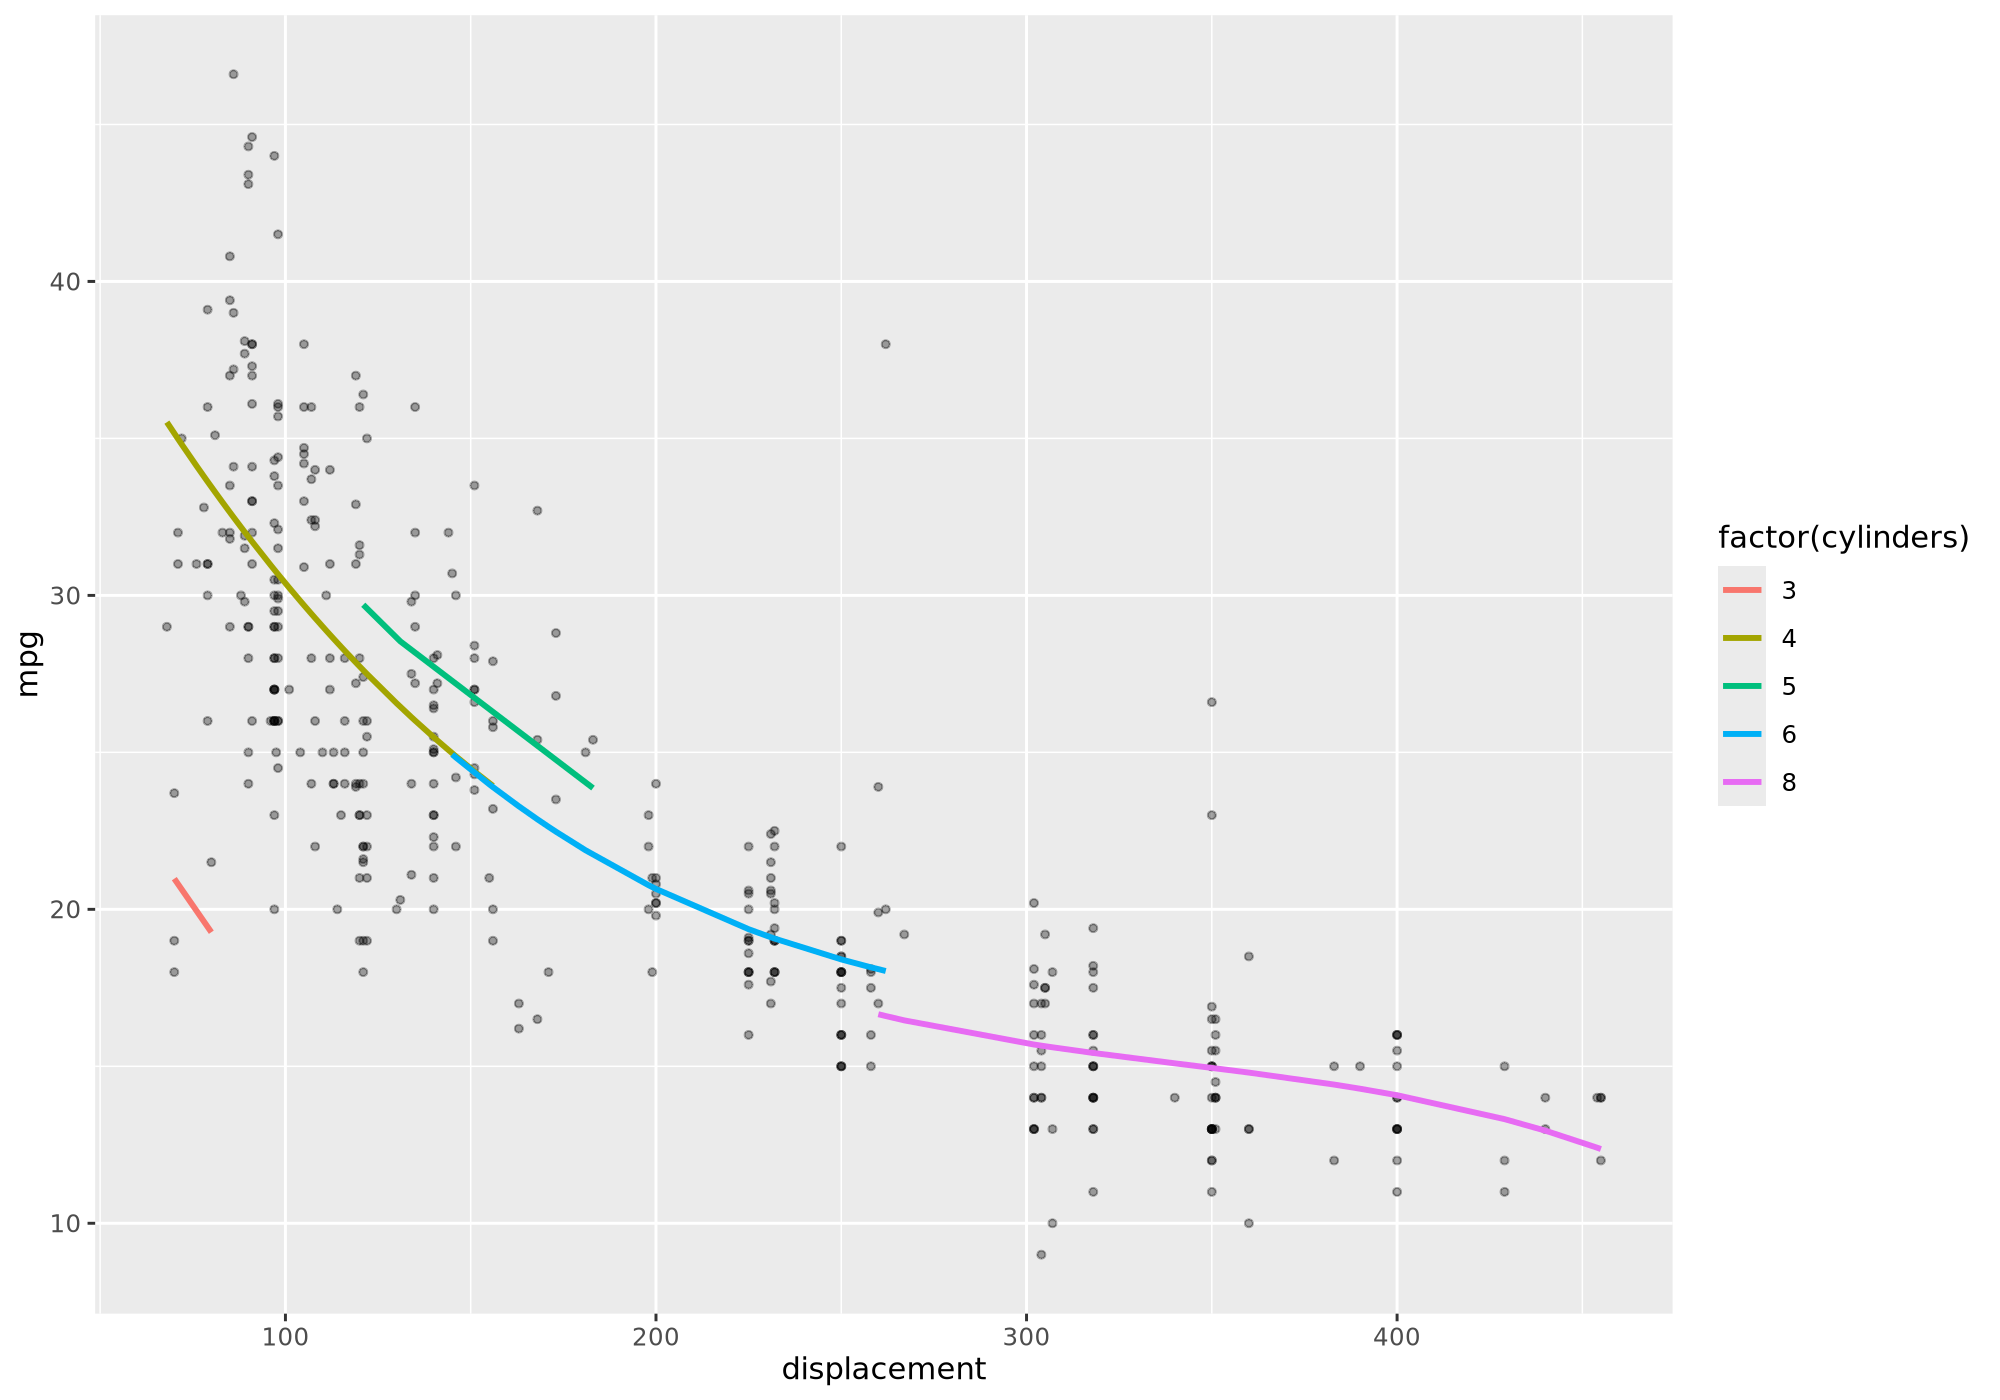

In [25]:
predict(mod_fit, rec |> juice()) |>
    bind_cols(Auto) |>
ggplot(aes(x = displacement, y = mpg)) +
    geom_point(size = 1, alpha = 0.35) +
    geom_line(aes(y = .pred, color = factor(cylinders)), linewidth = 1)